In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os
from nilearn.image import resample_to_img
from scipy import stats
from sklearn.linear_model import LinearRegression
import numpy as np
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import LinearSegmentedColormap


In [2]:
cond1_image = nib.load('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/bids_fmri_data/sub-19/derivatives/first_level/glm3/con_0001.nii')
cond1_data = cond1_image.get_fdata()

In [3]:
cond1_data.shape

(79, 95, 79)

In [4]:
np.isnan(cond1_data).sum()

377089

In [5]:
# setting nan values to zero
cond1_data = np.nan_to_num(cond1_data, nan=0.0)

In [6]:
np.isnan(cond1_data).sum()

0

## Functions

In [4]:
# Function to load and preprocess a single contrast image
def load_contrast_image(file_path):
    image = nib.load(file_path)
    data = image.get_fdata()
    data = np.nan_to_num(data, nan=0.0)
    return image, data

In [5]:
def compute_rdm(subject_data):
    """
    Compute the Representational Dissimilarity Matrix (RDM) for a single subject.
    
    :param subject_data: Dictionary containing the masked data for each condition
    :return: 6x6 RDM using correlation distance
    """
    # Combine data from all conditions into a single array
    condition_data = []
    for condition in range(1, 7):  # Assuming 6 conditions
        condition_key = f'condition_{condition}'
        if condition_key in subject_data:
            condition_data.append(subject_data[condition_key])
        else:
            print(f"Warning: {condition_key} not found for this subject")
            return None
    
    combined_data = np.array(condition_data)
    
    # Compute pairwise correlation distances
    rdm = pdist(combined_data, metric='correlation')
    
    # Convert to square form
    rdm_square = squareform(rdm)
    
    return rdm_square

In [6]:
# Function to apply resampled mask to a single subject's data
def apply_resampled_mask(subject_data, subject_images, mask_img):
    masked_data = {}
    for condition, image in subject_images.items():
        # Resample the mask to match the functional image
        resampled_mask_img = resample_to_img(mask_img, image, interpolation='nearest')
        resampled_mask_data = resampled_mask_img.get_fdata()
        
        # Apply the resampled mask
        masked_data[condition] = subject_data[condition][resampled_mask_data == 1]
    return masked_data

In [7]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM
    
    Args:
        RDM 2Darray: squareform RDM
    
    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [8]:
def rdm_regression_analysis_with_intercept(data_rdms, model_rdms):
    """
    Perform regression analysis on RDMs.
    
    Parameters:
    data_rdms (list): List of 6x6 numpy arrays representing data RDMs
    model_rdms (list): List of 6x6 numpy arrays representing model RDMs
    
    Returns:
    tuple: Numpy arrays containing betas, t-stats, and p-values
    """
    
    num_participants = len(data_rdms)
    num_regressors = len(model_rdms)
    
    # Initialize output arrays
    betas = np.zeros((num_participants, num_regressors))  # Only for the coefficients (no intercept)
    intercepts = np.zeros(num_participants)  # Separate array for intercepts
    
    # Convert model RDMs to column vectors
    X = np.column_stack([upper_tri(rdm) for rdm in model_rdms])
    
    for i, data_rdm in enumerate(data_rdms):
        y = upper_tri(data_rdm)
        model = LinearRegression(fit_intercept=True)
        model.fit(X, y)
        
        intercepts[i] = model.intercept_
        betas[i, :] = model.coef_
    
    return betas

In [9]:
def t_test_coefficients(betas):
    t_stats, p_values = stats.ttest_1samp(betas, popmean=0, axis=0)
    return t_stats, p_values

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

def plot_rdm(rdm, title="Group Average Nueral Data RDM - SN/VTA"):
    # Ensure the input is a numpy array
    rdm = np.array(rdm)
    
    # Set the style and color palette
    sns.set_style("white")  # Changed from "whitegrid" to "white"
    sns.set_palette("deep")
    
    # Set font sizes
    SMALL_SIZE = 10
    MEDIUM_SIZE = 14
    LARGE_SIZE = 22
    
    # Apply font sizes
    plt.rc('font', size=SMALL_SIZE)
    plt.rc('axes', titlesize=LARGE_SIZE)
    plt.rc('axes', labelsize=MEDIUM_SIZE)
    plt.rc('xtick', labelsize=MEDIUM_SIZE)
    plt.rc('ytick', labelsize=MEDIUM_SIZE)
    plt.rc('legend', fontsize=SMALL_SIZE)
    
    # Create a custom colormap
    colors = ['darkblue', 'turquoise', 'orange', 'yellow']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list("custom", colors, N=n_bins)
    
    # Create a new figure
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Plot the RDM without grid lines
    im = ax.imshow(rdm, cmap=cmap, interpolation='nearest', aspect='auto', vmin=0, vmax=2)
    
    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add a colorbar
    cbar = plt.colorbar(im)
    cbar.set_ticks([0, 0.5, 1, 1.5, 2])
    cbar.set_ticklabels(['0', '0.5', '1', '1.5', '2'])
    cbar.set_label('Dissimilarity', fontsize=MEDIUM_SIZE)
    
    # Set title
    ax.set_title(title, fontsize=LARGE_SIZE, pad=10)
    
    # Set labels
    conditions = ["Easy Env-Low Effort", "Easy Env-Mid Effort", "Easy Env-High Effort",
                  "Hard Env-Low Effort", "Hard Env-Mid Effort", "Hard Env-High Effort"]
    ax.set_xticks(range(rdm.shape[1]))
    ax.set_yticks(range(rdm.shape[0]))
    ax.set_xticklabels(conditions, rotation=45, ha='right')
    ax.set_yticklabels(conditions, rotation=45, ha='right')
    
    # Add text annotations in each cell
    # for i in range(rdm.shape[0]):
    #     for j in range(rdm.shape[1]):
    #         text_color = 'black'
    #         ax.text(j, i, f"{rdm[i, j]:.2f}", 
    #                 ha="center", va="center", color=text_color, fontweight='bold', fontsize=SMALL_SIZE)
    
    # Add thin lines around the cells
    for edge, spine in ax.spines.items():
        spine.set_visible(False)
    
    ax.set_xticks(np.arange(rdm.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(rdm.shape[0]+1)-.5, minor=True)
    # ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", size=0)
    
    # Adjust layout and display
    plt.tight_layout()
    plt.savefig('group_avg_SNVTA.png', dpi=300, bbox_inches='tight')
    plt.show()


## Model RDMs

In [11]:
# Define the model RDMs
immed_rdm = np.array([
    [0, 1, 2, 0, 1, 2],
    [1, 0, 1, 1, 0, 1],
    [2, 1, 0, 2, 1, 0],
    [0, 1, 2, 0, 1, 2],
    [1, 0, 1, 1, 0, 1],
    [2, 1, 0, 2, 1, 0]
])

backgnd_rdm = np.array([
    [0, 0, 0, 2, 2, 2],
    [0, 0, 0, 2, 2, 2],
    [0, 0, 0, 2, 2, 2],
    [2, 2, 2, 0, 0, 0],
    [2, 2, 2, 0, 0, 0],
    [2, 2, 2, 0, 0, 0]
])

back_imm_rdm1 = np.array([
    [0, 0.4, 0.8, 1.2, 1.6, 2],
    [0.4, 0, 0.4, 1.6, 1.2, 1.6],
    [0.8, 0.4, 0, 2, 1.6, 1.2],
    [1.2, 1.6, 2, 0, 0.4, 0.8],
    [1.6, 1.2, 1.6, 0.4, 0, 0.4],
    [2, 1.6, 1.2, 0.8, 0.4, 0]
])

back_imm_rdm2 = np.array([
    [0, 0.4, 0.8, 1.6, 1.8, 2],
    [0.4, 0, 0.4, 1.8, 1.6, 1.8],
    [0.8, 0.4, 0, 2, 1.8, 1.6],
    [1.6, 1.8, 2, 0, 0.4, 0.8],
    [1.8, 1.6, 1.8, 0.4, 0, 0.4],
    [2, 1.8, 1.6, 0.8, 0.4, 0]
])


back_imm_rdm3 = np.array([
    [0, 1, 2, 0, 1, 2],
    [1, 0, 1, 1, 0.5, 1],
    [2, 1, 0, 2, 1, 0],
    [0, 1, 2, 0, 1, 2],
    [1, 0.5, 1, 1, 0, 1],
    [2, 1, 0, 2, 1, 0]
])


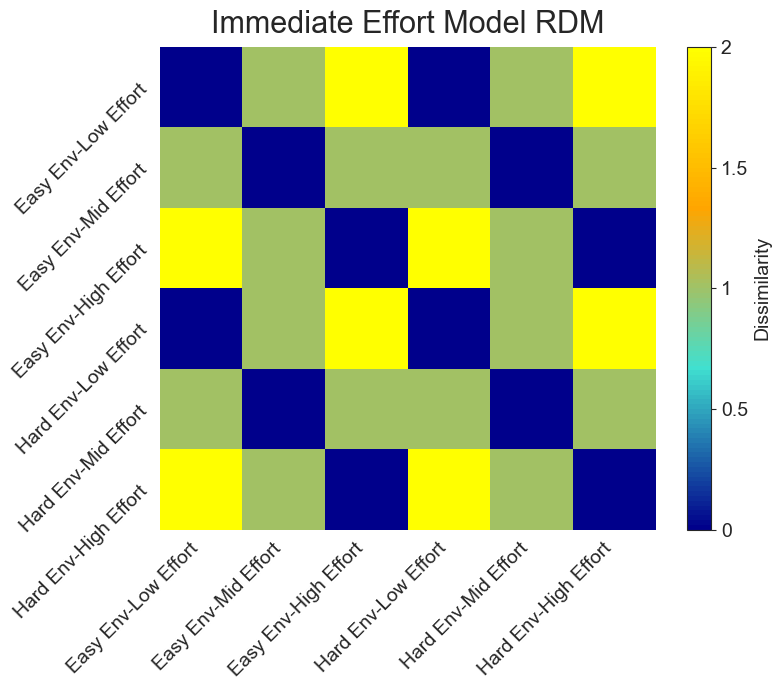

In [154]:
plot_rdm(immed_rdm)

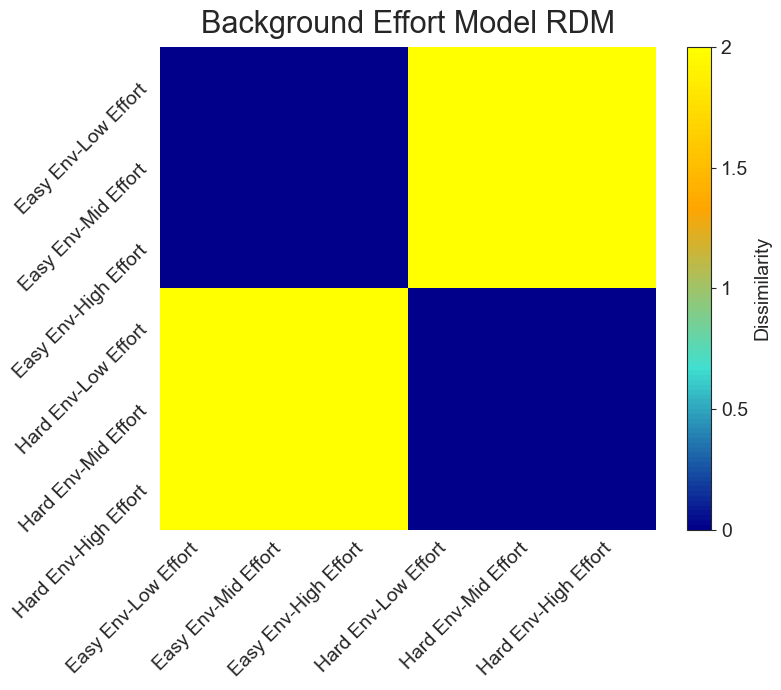

In [156]:
plot_rdm(backgnd_rdm)

In [162]:
# plot_rdm(back_imm_rdm1)

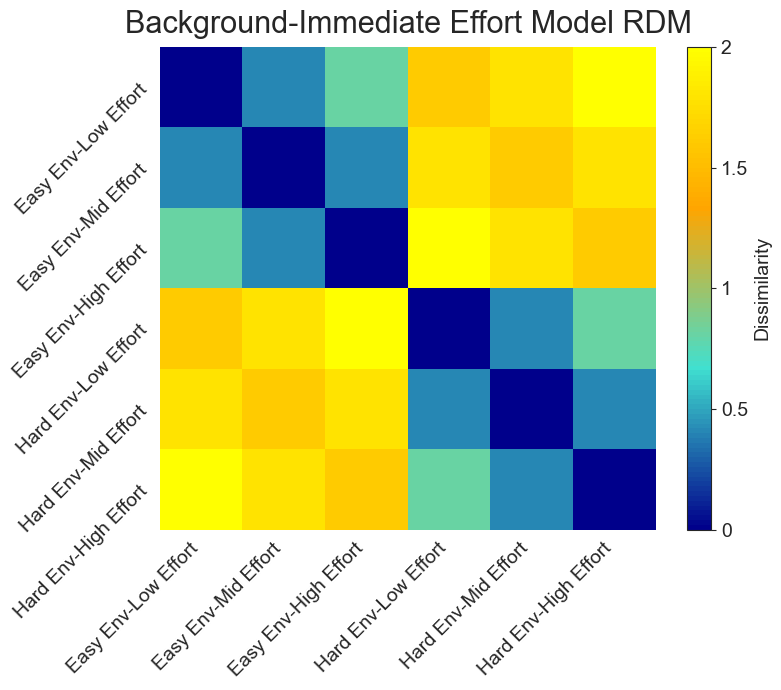

In [163]:
plot_rdm(back_imm_rdm2)

In [164]:
# plot_rdm(back_imm_rdm3)

In [273]:
def calculate_cross_correlation(data):
    # Flatten each array and stack them into a 2D array
    flattened_data = np.array([array.flatten() for array in data])
    
    # Calculate the correlation matrix
    corr_matrix = np.corrcoef(flattened_data)
    
    # Create labels for the matrix
    # labels = [f'Array{i+1}' for i in range(len(data))]
    labels = ['immed_rdm', 'backgnd_rdm', 'back_imm_rdm']
    
    # Create a formatted string to display the correlation matrix
    formatted_matrix = "Cross-Correlation Matrix:\n"
    formatted_matrix += "        " + " ".join(f"{label:>10}" for label in labels) + "\n"
    for i, row in enumerate(corr_matrix):
        formatted_matrix += f"{labels[i]:>10} " + " ".join(f"{value:10.4f}" for value in row) + "\n"
    
    return formatted_matrix

In [274]:
model_rdms = [immed_rdm, backgnd_rdm, back_imm_rdm2]
# model_rdms
['Immediate Effort', 'Background Effort','Background-Immediate Effort']

In [275]:
corrs = calculate_cross_correlation(model_rdms)

In [276]:
print(corrs)

Cross-Correlation Matrix:
         immed_rdm backgnd_rdm back_imm_rdm
 immed_rdm     1.0000     0.0000     0.2955
backgnd_rdm     0.0000     1.0000     0.9503
back_imm_rdm     0.2955     0.9503     1.0000



In [277]:
type(corrs)

str

In [292]:
def generate_correlation_heatmap(corr_matrix_string):
    # Extract the correlation values from the formatted string
    lines = corr_matrix_string.split('\n')[2:-1]  # Skip the header and empty last line
    corr_values = [list(map(float, line.split()[1:])) for line in lines]
    corr_matrix = np.array(corr_values)

    # Define custom labels
    custom_labels = ['Immediate Effort', 'Background Effort', 'Background-Immediate Effort']

    # Create the heatmap
    plt.figure(figsize=(8, 7))  # Increased figure size to accommodate longer labels
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                xticklabels=custom_labels, yticklabels=custom_labels)
    
    plt.title('Model RDM Correlations')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
    plt.yticks(rotation=45, ha='right') 
    plt.tight_layout()
    plt.savefig('model_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()

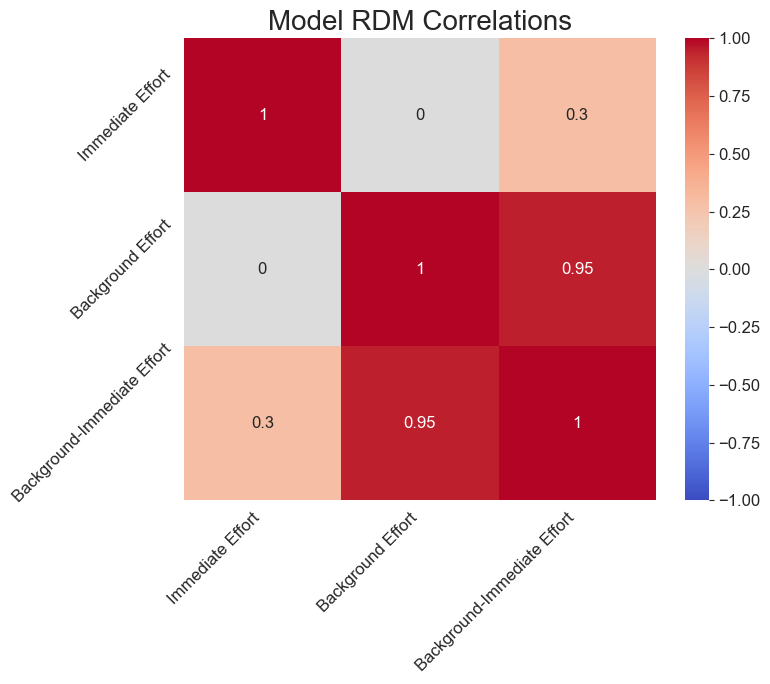

In [293]:
generate_correlation_heatmap(corrs)

## Get data for all participants

In [12]:
# Define the base directory and number of subjects/conditions
base_dir = '/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/bids_fmri_data'
subject_ids = ['sub-01', 'sub-02','sub-03','sub-04','sub-06','sub-07','sub-08','sub-09','sub-11','sub-12','sub-13','sub-14','sub-15','sub-16','sub-17','sub-18','sub-19']
num_conditions = 6

In [13]:
# Dictionary to store data for all subjects and conditions
all_data = {}
all_images = {}  # To store NIfTI image objects

# Loop through subjects and conditions
for subject_id in subject_ids:
    all_data[subject_id] = {}
    all_images[subject_id] = {}
    
    for condition in range(1, num_conditions + 1):
        file_name = f'con_{condition:04d}.nii'
        file_path = os.path.join(base_dir, subject_id, 'derivatives', 'first_level', 'glm3', file_name)
        
        if os.path.exists(file_path):
            image, data = load_contrast_image(file_path)
            all_data[subject_id][f'condition_{condition}'] = data
            all_images[subject_id][f'condition_{condition}'] = image
        else:
            print(f"Warning: File not found for {subject_id}, condition {condition}")

In [75]:
all_data['sub-01']['condition_1'].size

592895

## Apply ROI mask

### dmPFC

In [14]:
# Load the mask image
mask_path = '/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/dmPFC.nii'  
mask_img = nib.load(mask_path)
# mask_data = mask_image.get_fdata()


In [15]:
# Apply resampled mask to all subjects
masked_all_data = {}
for subject_id in all_data.keys():
    masked_all_data[subject_id] = apply_resampled_mask(all_data[subject_id], all_images[subject_id], mask_img)

In [16]:
masked_all_data['sub-11']['condition_6'].size

1340

In [17]:
# Compute RDM for all subjects
all_rdms = {}
for subject_id, subject_data in masked_all_data.items():
    rdm = compute_rdm(subject_data)
    if rdm is not None:
        all_rdms[subject_id] = rdm

# Now all_rdms contains the 6x6 RDM for each subject
# You can access the RDM for a specific subject like this:
# rdm_for_subject_01 = all_rdms['sub-01']


In [18]:
# Initialize an empty list to store the matrices
all_rdms_matrices = list(all_rdms.values())

# Compute the sum of all matrices
sum_matrix = np.sum(all_rdms_matrices, axis=0)

# Compute the average matrix
average_matrix = sum_matrix / len(all_rdms_matrices)

# print(average_matrix)

In [19]:
average_matrix

array([[0.        , 0.47889994, 0.48011168, 0.55952519, 0.66512399,
        0.67288927],
       [0.47889994, 0.        , 0.51769502, 0.4876114 , 0.57300273,
        0.65962476],
       [0.48011168, 0.51769502, 0.        , 0.56084127, 0.57933879,
        0.47707398],
       [0.55952519, 0.4876114 , 0.56084127, 0.        , 0.3542789 ,
        0.41281939],
       [0.66512399, 0.57300273, 0.57933879, 0.3542789 , 0.        ,
        0.49994775],
       [0.67288927, 0.65962476, 0.47707398, 0.41281939, 0.49994775,
        0.        ]])

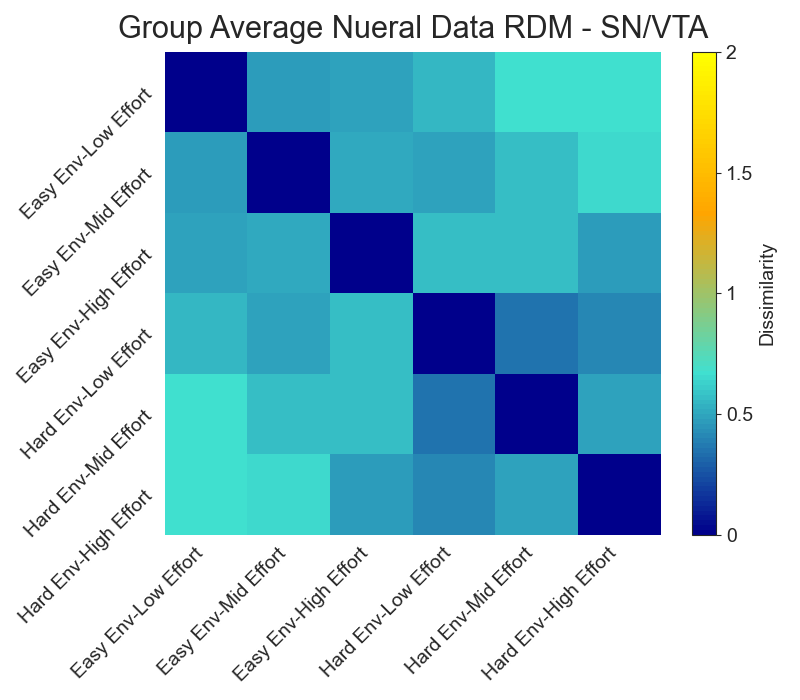

In [462]:
plot_rdm(average_matrix)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from sklearn.manifold import MDS

def flip_and_fold(RDM):
    size = RDM.shape[0]
    new_RDM = np.zeros_like(RDM)
    for i in range(size):
        for j in range(size):
            v = [RDM[i, j], RDM[j, i]]
            mean_val = np.mean(v)
            new_RDM[i, j] = mean_val
            new_RDM[j, i] = mean_val
    np.fill_diagonal(new_RDM, 0)
    return new_RDM

def plot_mds_homework(r):
    # Run MDS
    mds = MDS(n_components=3, dissimilarity='precomputed', random_state=0)
    Y = mds.fit_transform(r)
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Define labels and colors for the conditions
    labels = ["Easy-Low", "Easy-Mid", "Easy-High",
                  "Hard-Low", "Hard-Mid", "Hard-High"]
    colors = ['b', 'b', 'b', 'r', 'r', 'r']
    
    # Plotting the points
    for idx, (label, color) in enumerate(zip(labels, colors)):
        ax.scatter(Y[idx, 0], Y[idx, 1], Y[idx, 2], c=color, marker='o', s=20)
        ax.text(Y[idx, 0], Y[idx, 1], Y[idx, 2], '  ' + label, color=color, fontsize=10)
    
    # Connect the points within each block type
    easy_indices = [0, 1, 2, 0]  # Indices for Easy block type
    hard_indices = [3, 4, 5, 3]  # Indices for Hard block type
    
    easy_x = [Y[i, 0] for i in easy_indices]
    easy_y = [Y[i, 1] for i in easy_indices]
    easy_z = [Y[i, 2] for i in easy_indices]
    ax.plot(easy_x, easy_y, easy_z, 'b-')
    
    hard_x = [Y[i, 0] for i in hard_indices]
    hard_y = [Y[i, 1] for i in hard_indices]
    hard_z = [Y[i, 2] for i in hard_indices]
    ax.plot(hard_x, hard_y, hard_z, 'r-')
    
    # Set axis labels
    ax.set_xlabel('MDS Dim 1', fontsize=10)
    ax.set_ylabel('MDS Dim 2', fontsize=10)
    ax.set_zlabel('MDS Dim 3', fontsize=10)
    
    # Set tick label font size
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.tick_params(axis='both', which='minor', labelsize=8)

    # Adjust layout
    plt.tight_layout()
    
    # plt.savefig('MDS_SNVTA.png', dpi=300, bbox_inches='tight', pad_inches=0.3)
    plt.show()


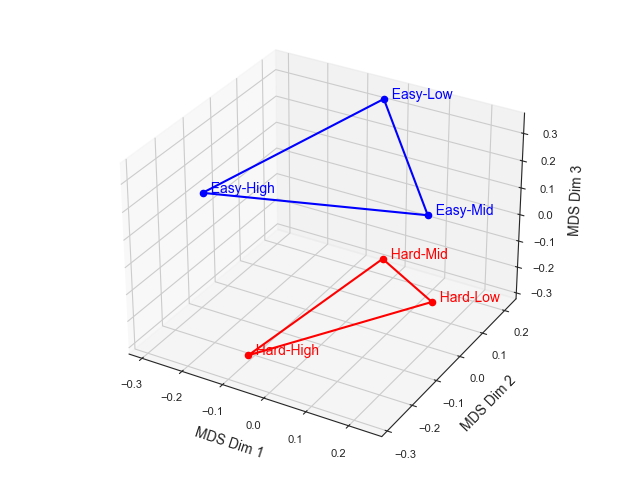

In [467]:
# Apply flip and fold
to_plot = flip_and_fold(average_matrix)

# Plot MDS result
plot_mds_homework(to_plot)

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import MDS
%matplotlib widget 

def plot_mds_homework_3d(r):
    # Run MDS
    mds = MDS(n_components=3, dissimilarity='precomputed', random_state=0)
    Y = mds.fit_transform(r)
    
    # Create an interactive figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Define labels and colors for the conditions
    labels = ["Easy-Low", "Easy-Mid", "Easy-High",
              "Hard-Low", "Hard-Mid", "Hard-High"]
    colors = ['b', 'b', 'b', 'r', 'r', 'r']
    
    # Plotting the points
    for idx, (label, color) in enumerate(zip(labels, colors)):
        ax.scatter(Y[idx, 0], Y[idx, 1], Y[idx, 2], c=color, marker='o', s=20)
        ax.text(Y[idx, 0], Y[idx, 1], Y[idx, 2], '  ' + label, color=color, fontsize=16)
    
    # Connect the points within each block type
    easy_indices = [0, 1, 2, 0]  # Indices for Easy block type
    hard_indices = [3, 4, 5, 3]  # Indices for Hard block type
    
    easy_x = [Y[i, 0] for i in easy_indices]
    easy_y = [Y[i, 1] for i in easy_indices]
    easy_z = [Y[i, 2] for i in easy_indices]
    ax.plot(easy_x, easy_y, easy_z, 'b-')
    
    hard_x = [Y[i, 0] for i in hard_indices]
    hard_y = [Y[i, 1] for i in hard_indices]
    hard_z = [Y[i, 2] for i in hard_indices]
    ax.plot(hard_x, hard_y, hard_z, 'r-')
    
    # Set axis labels
    ax.set_xlabel('MDS Dim 1', fontsize=14)
    ax.set_ylabel('MDS Dim 2', fontsize=14)
    ax.set_zlabel('MDS Dim 3', fontsize=14)
    
    # Set tick label font size
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.tick_params(axis='both', which='minor', labelsize=8)
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the interactive plot
    plt.show()
    
    return fig, ax

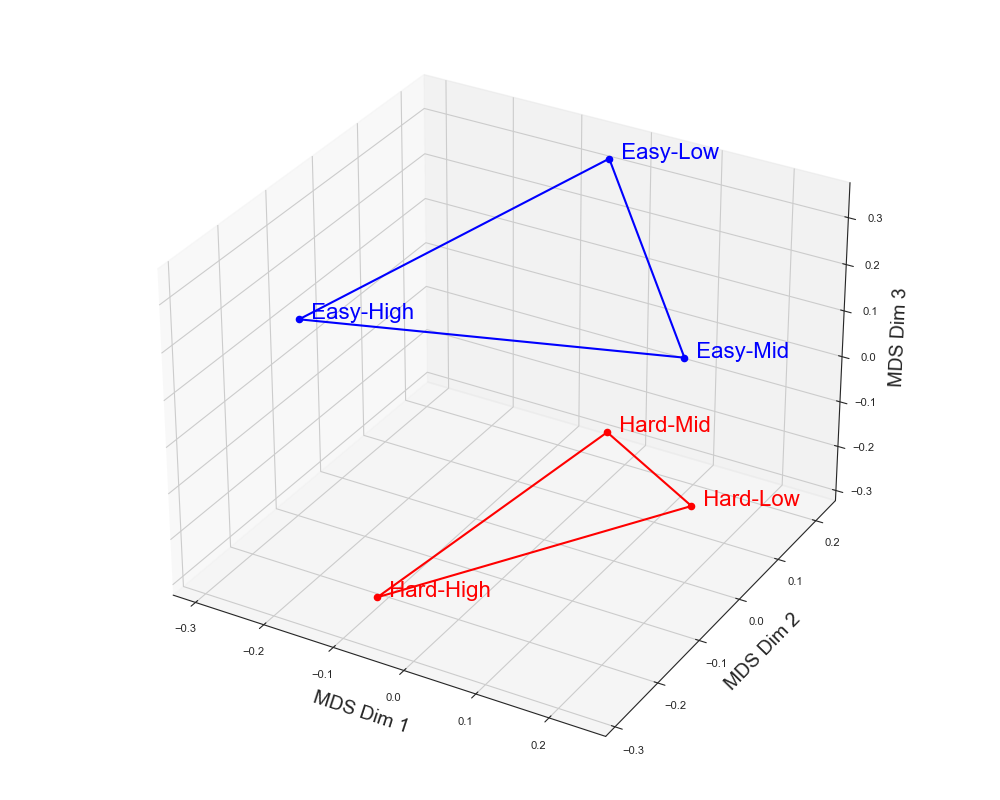

In [469]:
fig, ax = plot_mds_homework_3d(to_plot)

In [19]:
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

def plot_mds_homework_2d(r):
    # Run MDS
    mds = MDS(n_components=3, dissimilarity='precomputed', random_state=0)
    Y = mds.fit_transform(r)
    
    # Create a figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Define labels and colors for the conditions
    labels = ["Easy-Low", "Easy-Mid", "Easy-High",
              "Hard-Low", "Hard-Mid", "Hard-High"]
    colors = ['b', 'b', 'b', 'r', 'r', 'r']
    
    # Plotting the points
    for idx, (label, color) in enumerate(zip(labels, colors)):
        ax.scatter(Y[idx, 0], Y[idx, 1], c=color, marker='o', s=20)
        ax.annotate(label, (Y[idx, 0], Y[idx, 1]), xytext=(5, 5), textcoords='offset points', fontsize=16)
    
    # Connect the points within each block type
    easy_indices = [0, 1, 2, 0]  # Indices for Easy block type
    hard_indices = [3, 4, 5, 3]  # Indices for Hard block type
    
    easy_x = [Y[i, 0] for i in easy_indices]
    easy_y = [Y[i, 1] for i in easy_indices]
    ax.plot(easy_x, easy_y, 'b-')
    
    hard_x = [Y[i, 0] for i in hard_indices]
    hard_y = [Y[i, 1] for i in hard_indices]
    ax.plot(hard_x, hard_y, 'r-')
    
    # Set axis labels
    ax.set_xlabel('MDS Dim 1', fontsize=14)
    ax.set_ylabel('MDS Dim 2', fontsize=14)
    
    # Set tick label font size
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.tick_params(axis='both', which='minor', labelsize=8)
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    
    return fig, ax  # Return the figure and axes objects for further manipulation if needed

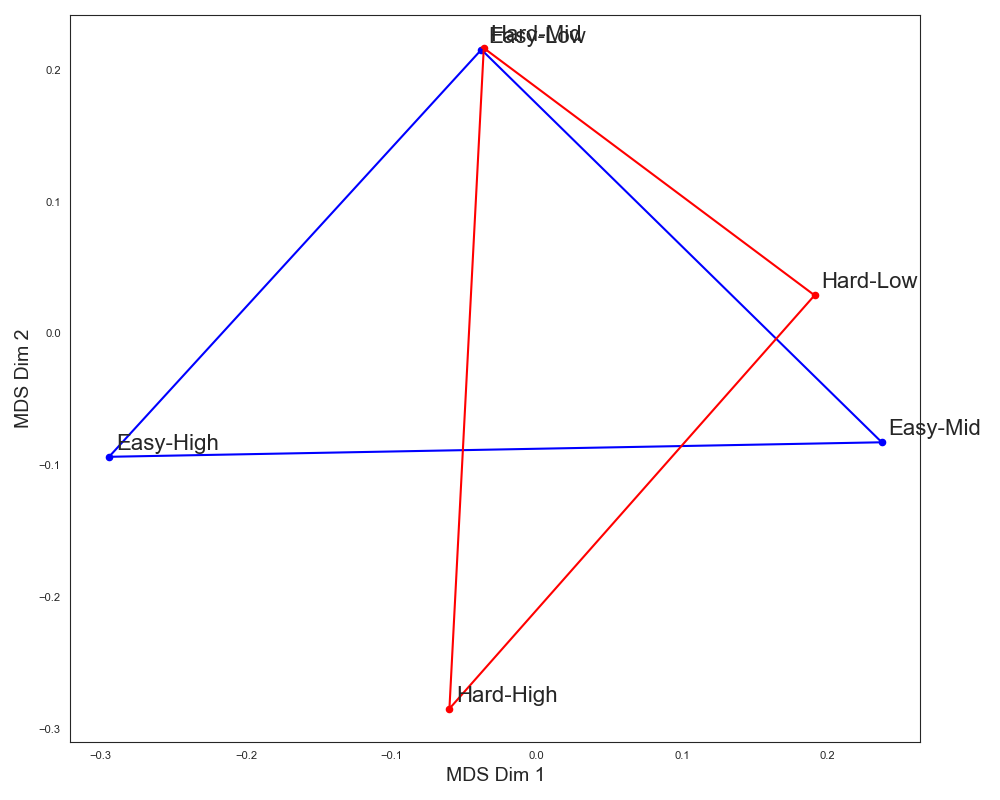

In [471]:
# Usage
fig, ax = plot_mds_homework_2d(to_plot)  # Assuming 'r' is your dissimilarity matrix

### Regression analysis

In [223]:
# model_rdms = [immed_rdm, backgnd_rdm, back_imm_rdm2]
model_rdms = [immed_rdm, backgnd_rdm]

# Perform regression analysis
betas = rdm_regression_analysis_with_intercept(all_rdms_matrices, model_rdms)

In [224]:
type(betas)

numpy.ndarray

In [225]:
# Perform t-tests on coefficients
group_t_stats, group_p_values = t_test_coefficients(betas)

# Print rzesults
regressor_names = ['Immediate', 'Background', 'Back-Imm']
print("Group-level statistics:")
for name, t_stat, p_value in zip(regressor_names, group_t_stats, group_p_values):
    print(f"{name}: t = {t_stat:.4f}, p = {p_value:.8f}")

Group-level statistics:
Immediate: t = 1.3604, p = 0.19257378
Background: t = 3.3426, p = 0.00413149


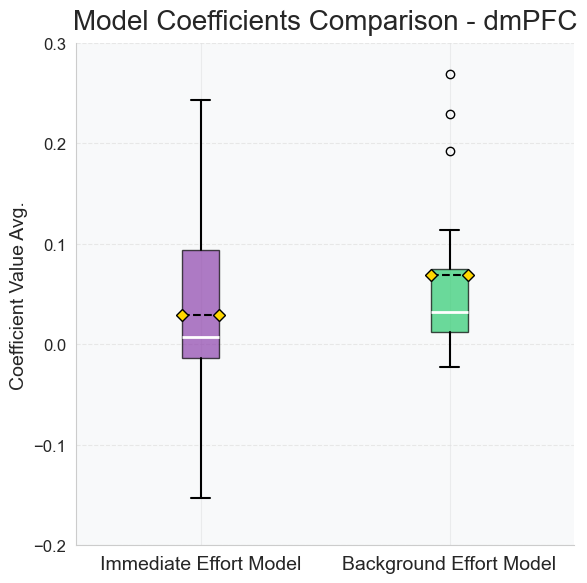

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style and color palette
sns.set_style("whitegrid")
sns.set_palette("deep")

# Adjust gridline transparency
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Set font sizes
SMALL_SIZE = 12
MEDIUM_SIZE = 14
LARGE_SIZE = 20

# Apply font sizes
plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=LARGE_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the boxplot
bp = ax.boxplot(betas, patch_artist=True, meanline=True, showmeans=True)

# Customize boxplot colors
colors = ['#8e44ad', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize other elements
for element in ['whiskers', 'caps', 'medians', 'means']:
    plt.setp(bp[element], color='black', linewidth=1.5)

plt.setp(bp['medians'], color='white', linewidth=2)
plt.setp(bp['means'], marker='D', markeredgecolor='black', markerfacecolor='gold')

# Customize the plot
ax.set_title('Model Coefficients Comparison - dmPFC', fontsize=LARGE_SIZE, pad=10)
ax.set_xticklabels(['Immediate Effort Model', 'Background Effort Model'], fontsize=MEDIUM_SIZE)
ax.set_ylabel('Coefficient Value Avg.', fontsize=MEDIUM_SIZE)
ax.set_ylim(-.2, 0.3)  # Adjust the limits according to your data

# Add a subtle background color
ax.set_facecolor('#f8f9fa')

# Add grid lines
ax.yaxis.grid(True, linestyle='--', which='major', color='#e0e0e0', alpha=0.7)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('model_coefficients_dmPFC.png', dpi=300, bbox_inches='tight')
plt.show()

### vmPFC

In [472]:
# Load the mask image
mask_path = '/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/vmPFC_bin.nii'  
mask_img = nib.load(mask_path)
# mask_data = mask_image.get_fdata()


In [473]:
# Apply resampled mask to all subjects
masked_all_data = {}
for subject_id in all_data.keys():
    masked_all_data[subject_id] = apply_resampled_mask(all_data[subject_id], all_images[subject_id], mask_img)

In [474]:
masked_all_data['sub-11']['condition_6'].size

939

In [475]:
# Compute RDM for all subjects
all_rdms = {}
for subject_id, subject_data in masked_all_data.items():
    rdm = compute_rdm(subject_data)
    if rdm is not None:
        all_rdms[subject_id] = rdm

# Now all_rdms contains the 6x6 RDM for each subject
# You can access the RDM for a specific subject like this:
# rdm_for_subject_01 = all_rdms['sub-01']


In [476]:
# Initialize an empty list to store the matrices
all_rdms_matrices = list(all_rdms.values())

# Compute the sum of all matrices
sum_matrix = np.sum(all_rdms_matrices, axis=0)

# Compute the average matrix
average_matrix = sum_matrix / len(all_rdms_matrices)


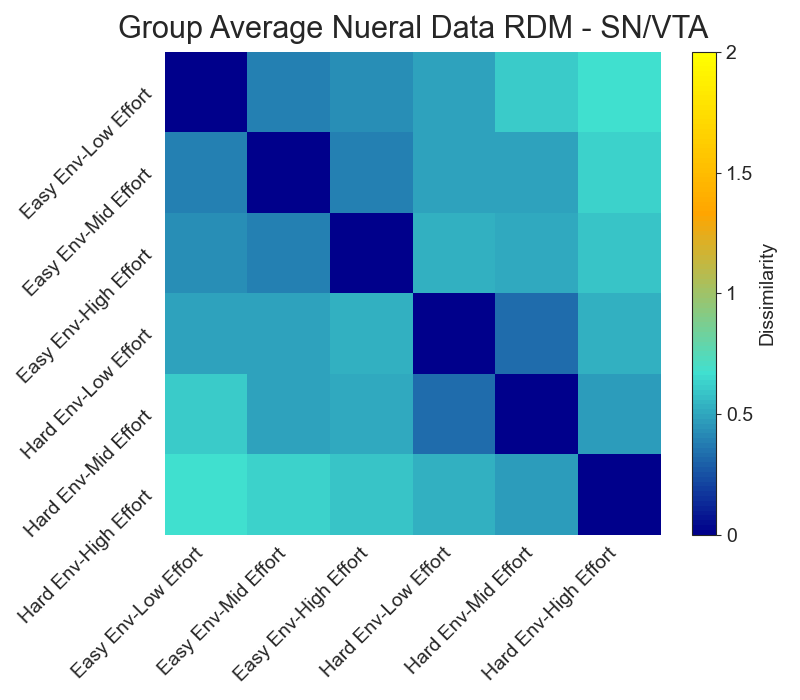

In [477]:
plot_rdm(average_matrix)

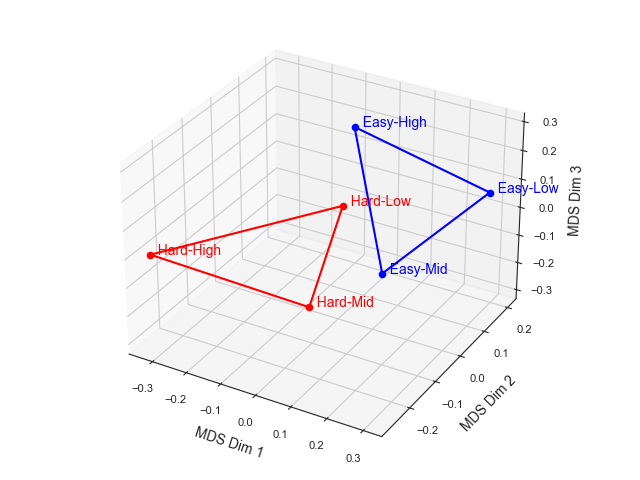

In [478]:
# Apply flip and fold
to_plot = flip_and_fold(average_matrix)

# Plot MDS result
plot_mds_homework(to_plot)

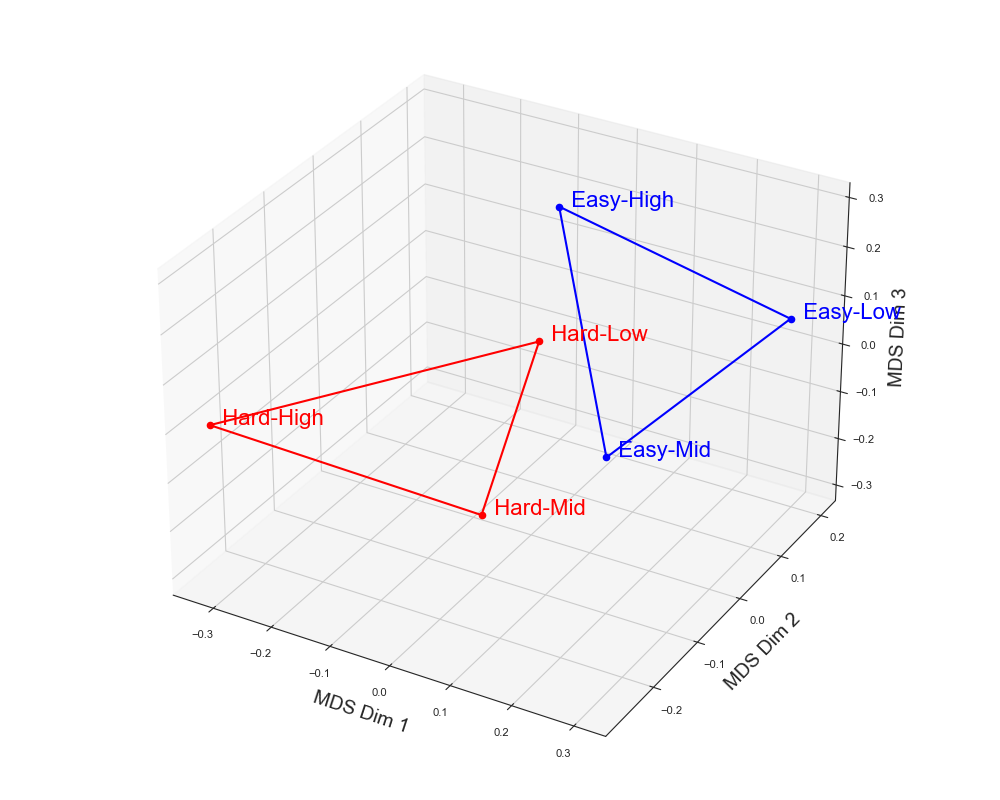

In [479]:
fig, ax = plot_mds_homework_3d(to_plot)

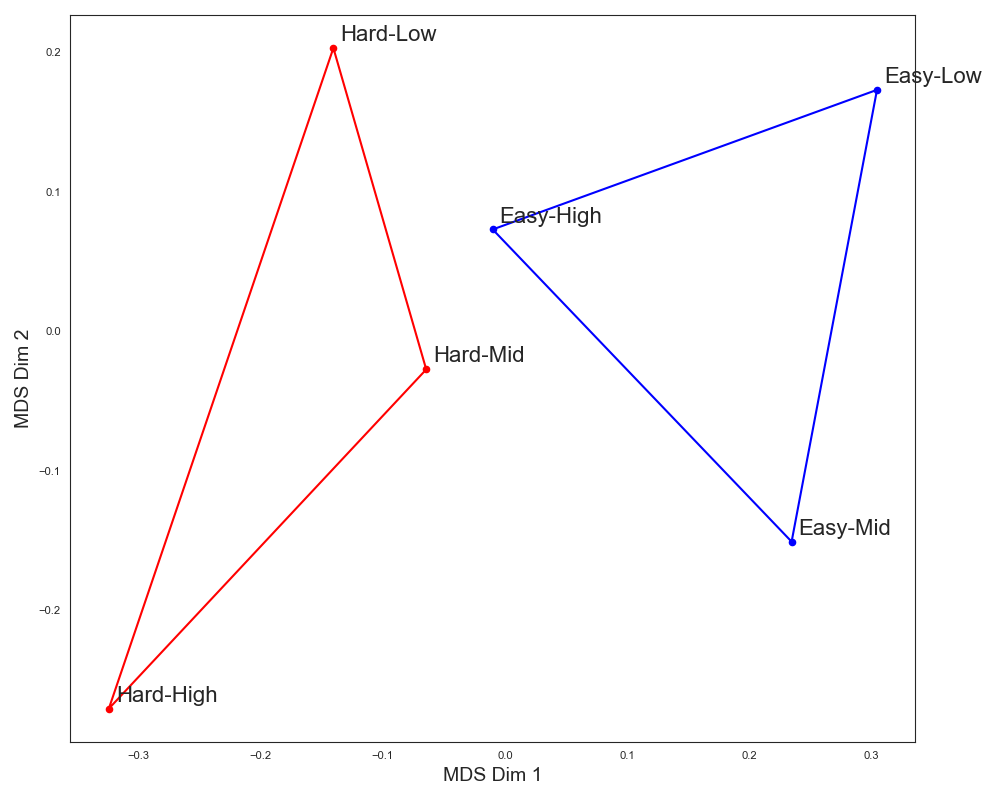

In [480]:
# Usage
fig, ax = plot_mds_homework_2d(to_plot)  # Assuming 'r' is your dissimilarity matrix

### Regression analysis

In [195]:
# model_rdms = [immed_rdm, backgnd_rdm, back_imm_rdm2]
model_rdms = [immed_rdm, backgnd_rdm]

# Perform regression analysis
betas = rdm_regression_analysis_with_intercept(all_rdms_matrices, model_rdms)

In [196]:
# Perform t-tests on coefficients
group_t_stats, group_p_values = t_test_coefficients(betas)

# Print rzesults
regressor_names = ['Immediate', 'Background', 'Back-Imm']
print("Group-level statistics:")
for name, t_stat, p_value in zip(regressor_names, group_t_stats, group_p_values):
    print(f"{name}: t = {t_stat:.4f}, p = {p_value:.8f}")

Group-level statistics:
Immediate: t = 2.8407, p = 0.01180594
Background: t = 5.4390, p = 0.00005461


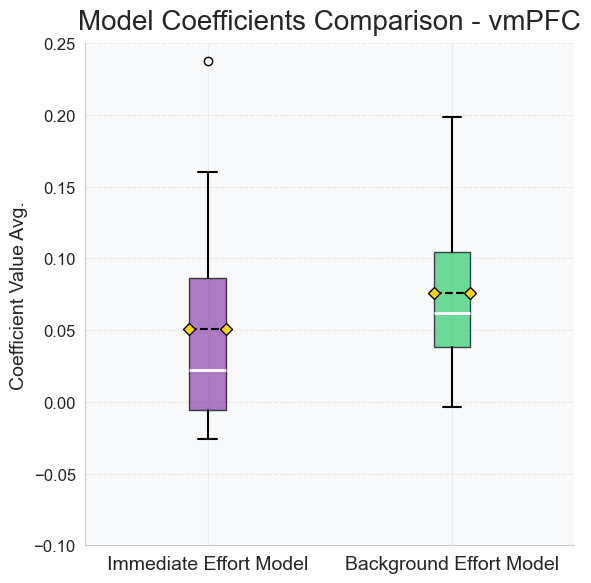

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style and color palette
sns.set_style("whitegrid")
sns.set_palette("deep")

# Adjust gridline transparency
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Set font sizes
SMALL_SIZE = 12
MEDIUM_SIZE = 14
LARGE_SIZE = 20

# Apply font sizes
plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=LARGE_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the boxplot
bp = ax.boxplot(betas, patch_artist=True, meanline=True, showmeans=True)

# Customize boxplot colors
colors = ['#8e44ad', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize other elements
for element in ['whiskers', 'caps', 'medians', 'means']:
    plt.setp(bp[element], color='black', linewidth=1.5)

plt.setp(bp['medians'], color='white', linewidth=2)
plt.setp(bp['means'], marker='D', markeredgecolor='black', markerfacecolor='gold')

# Customize the plot
ax.set_title('Model Coefficients Comparison - vmPFC', fontsize=LARGE_SIZE, pad=10)
ax.set_xticklabels(['Immediate Effort Model', 'Background Effort Model'], fontsize=MEDIUM_SIZE)
ax.set_ylabel('Coefficient Value Avg.', fontsize=MEDIUM_SIZE)
ax.set_ylim(-.1, 0.25)  # Adjust the limits according to your data

# Add a subtle background color
ax.set_facecolor('#f8f9fa')

# Add grid lines
ax.yaxis.grid(True, linestyle='--', which='major', color='#e0e0e0', alpha=0.7)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('model_coefficients_vmPFC.png', dpi=300, bbox_inches='tight')
plt.show()

### SN/VTA

In [481]:
# Load the mask image
mask_path = '/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/corrected_MNI_res-epi_label-VTASN_mask.nii'  
mask_img = nib.load(mask_path)
# mask_data = mask_image.get_fdata()


In [482]:
# Apply resampled mask to all subjects
masked_all_data = {}
for subject_id in all_data.keys():
    masked_all_data[subject_id] = apply_resampled_mask(all_data[subject_id], all_images[subject_id], mask_img)

In [483]:
masked_all_data['sub-11']['condition_6'].size

226

In [484]:
# Compute RDM for all subjects
all_rdms = {}
for subject_id, subject_data in masked_all_data.items():
    rdm = compute_rdm(subject_data)
    if rdm is not None:
        all_rdms[subject_id] = rdm

# Now all_rdms contains the 6x6 RDM for each subject
# You can access the RDM for a specific subject like this:
# rdm_for_subject_01 = all_rdms['sub-01']


In [485]:
# Initialize an empty list to store the matrices
all_rdms_matrices = list(all_rdms.values())

# Compute the sum of all matrices
sum_matrix = np.sum(all_rdms_matrices, axis=0)

# Compute the average matrix
average_matrix = sum_matrix / len(all_rdms_matrices)


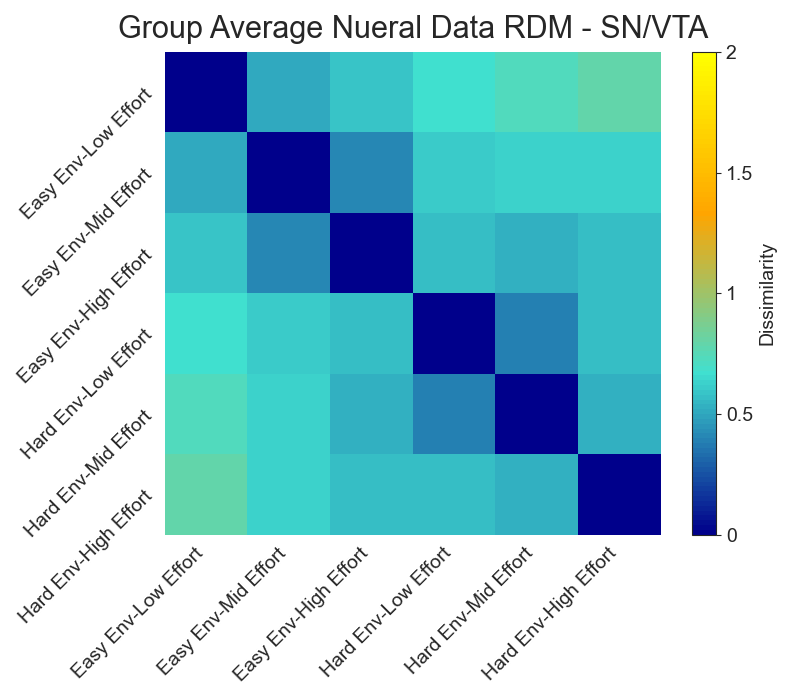

In [486]:
plot_rdm(average_matrix)

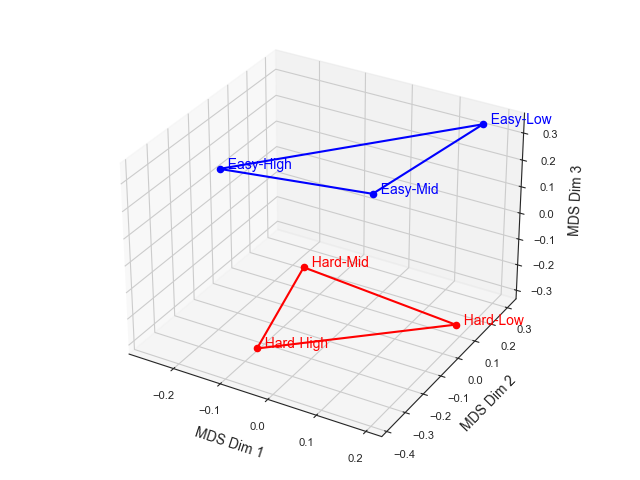

In [487]:
# Apply flip and fold
to_plot = flip_and_fold(average_matrix)

# Plot MDS result
plot_mds_homework(to_plot)

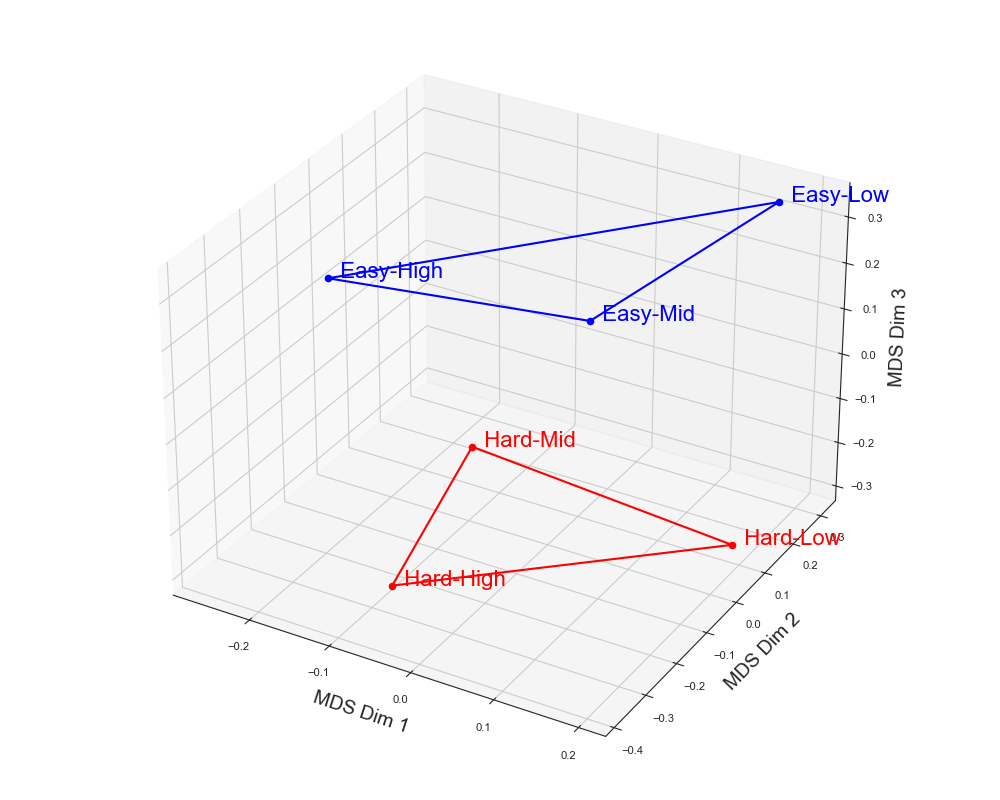

In [488]:
fig, ax = plot_mds_homework_3d(to_plot)

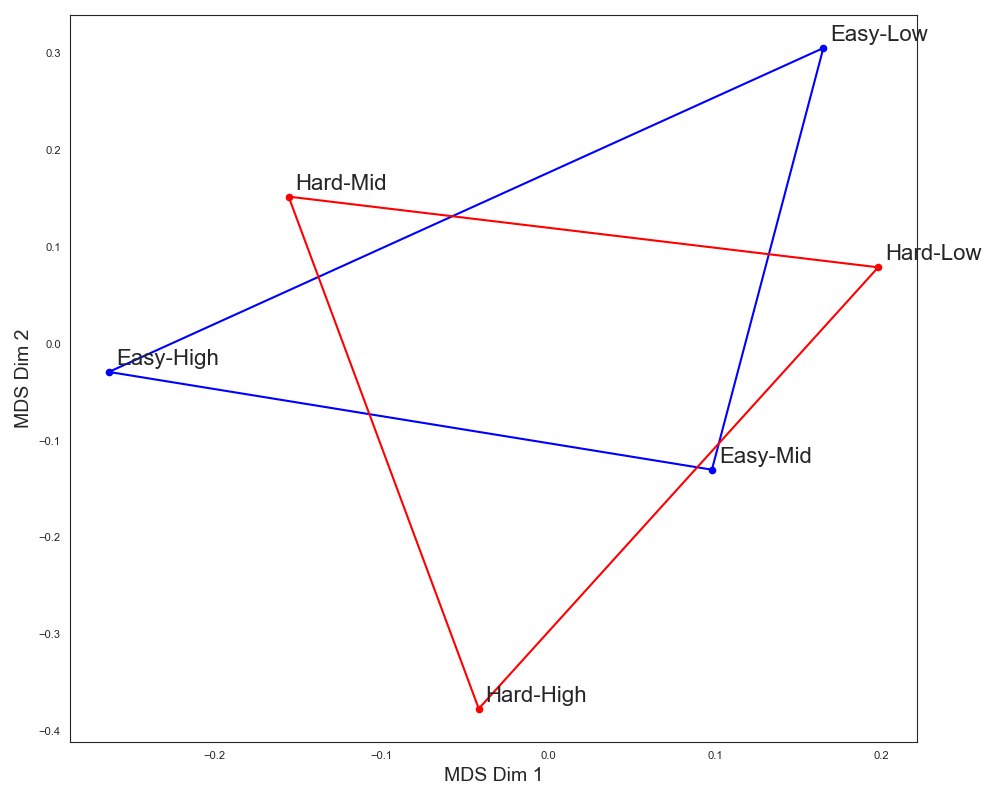

In [489]:
# Usage
fig, ax = plot_mds_homework_2d(to_plot)  # Assuming 'r' is your dissimilarity matrix

### Regression analysis

In [238]:
# model_rdms = [immed_rdm, backgnd_rdm, back_imm_rdm2]
model_rdms = [immed_rdm, backgnd_rdm]

# Perform regression analysis
betas = rdm_regression_analysis_with_intercept(all_rdms_matrices, model_rdms)

In [239]:
# Perform t-tests on coefficients
group_t_stats, group_p_values = t_test_coefficients(betas)

# Print rzesults
regressor_names = ['Immediate', 'Background', 'Back-Imm']
print("Group-level statistics:")
for name, t_stat, p_value in zip(regressor_names, group_t_stats, group_p_values):
    print(f"{name}: t = {t_stat:.4f}, p = {p_value:.8f}")

Group-level statistics:
Immediate: t = 2.1779, p = 0.04471727
Background: t = 5.6664, p = 0.00003505


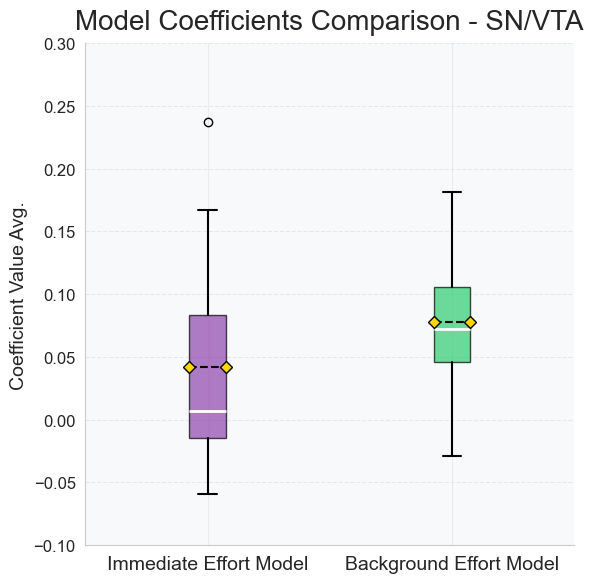

In [241]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style and color palette
sns.set_style("whitegrid")
sns.set_palette("deep")

# Adjust gridline transparency
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Set font sizes
SMALL_SIZE = 12
MEDIUM_SIZE = 14
LARGE_SIZE = 20

# Apply font sizes
plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=LARGE_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the boxplot
bp = ax.boxplot(betas, patch_artist=True, meanline=True, showmeans=True)

# Customize boxplot colors
colors = ['#8e44ad', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize other elements
for element in ['whiskers', 'caps', 'medians', 'means']:
    plt.setp(bp[element], color='black', linewidth=1.5)

plt.setp(bp['medians'], color='white', linewidth=2)
plt.setp(bp['means'], marker='D', markeredgecolor='black', markerfacecolor='gold')

# Customize the plot
ax.set_title('Model Coefficients Comparison - SN/VTA', fontsize=LARGE_SIZE, pad=10)
ax.set_xticklabels(['Immediate Effort Model', 'Background Effort Model'], fontsize=MEDIUM_SIZE)
ax.set_ylabel('Coefficient Value Avg.', fontsize=MEDIUM_SIZE)
ax.set_ylim(-.1, 0.3)  # Adjust the limits according to your data

# Add a subtle background color
ax.set_facecolor('#f8f9fa')

# Add grid lines
ax.yaxis.grid(True, linestyle='--', which='major', color='#e0e0e0', alpha=0.7)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('model_coefficients_SNVTA.png', dpi=300, bbox_inches='tight')
plt.show()

### TPJ (temporoparietal junction), control region

In [20]:
# Load the mask image
mask_path = '/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/masks/neurovault/l_TPJ.nii.gz'  
mask_img = nib.load(mask_path)
# mask_data = mask_image.get_fdata()


In [21]:
# Apply resampled mask to all subjects
masked_all_data = {}
for subject_id in all_data.keys():
    masked_all_data[subject_id] = apply_resampled_mask(all_data[subject_id], all_images[subject_id], mask_img)

In [22]:
masked_all_data['sub-11']['condition_6'].size

489

In [23]:
# Compute RDM for all subjects
all_rdms = {}
for subject_id, subject_data in masked_all_data.items():
    rdm = compute_rdm(subject_data)
    if rdm is not None:
        all_rdms[subject_id] = rdm

# Now all_rdms contains the 6x6 RDM for each subject
# You can access the RDM for a specific subject like this:
# rdm_for_subject_01 = all_rdms['sub-01']


In [24]:
# Initialize an empty list to store the matrices
all_rdms_matrices = list(all_rdms.values())

# Compute the sum of all matrices
sum_matrix = np.sum(all_rdms_matrices, axis=0)

# Compute the average matrix
average_matrix = sum_matrix / len(all_rdms_matrices)


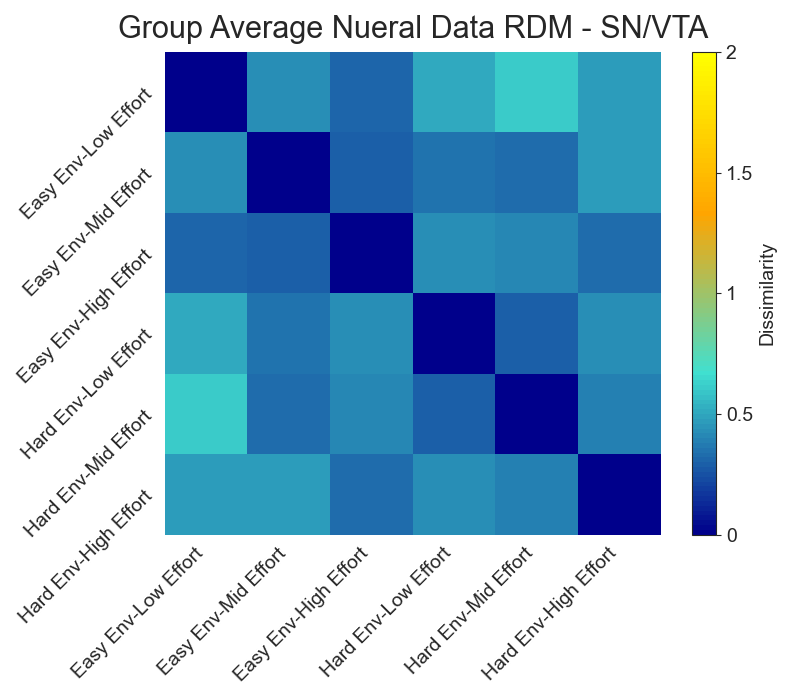

In [25]:
plot_rdm(average_matrix)

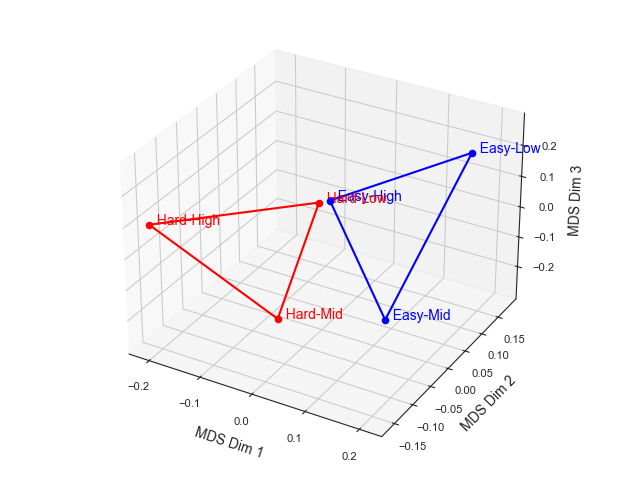

In [26]:
# Apply flip and fold
to_plot = flip_and_fold(average_matrix)

# Plot MDS result
plot_mds_homework(to_plot)

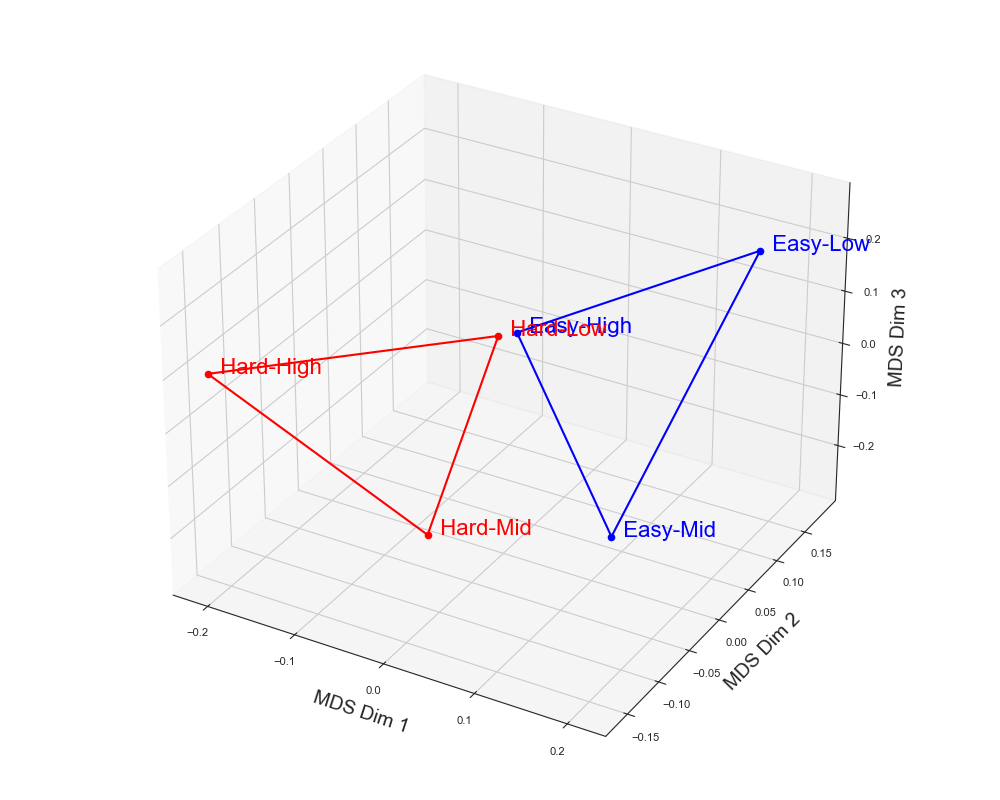

In [28]:
fig, ax = plot_mds_homework_3d(to_plot)

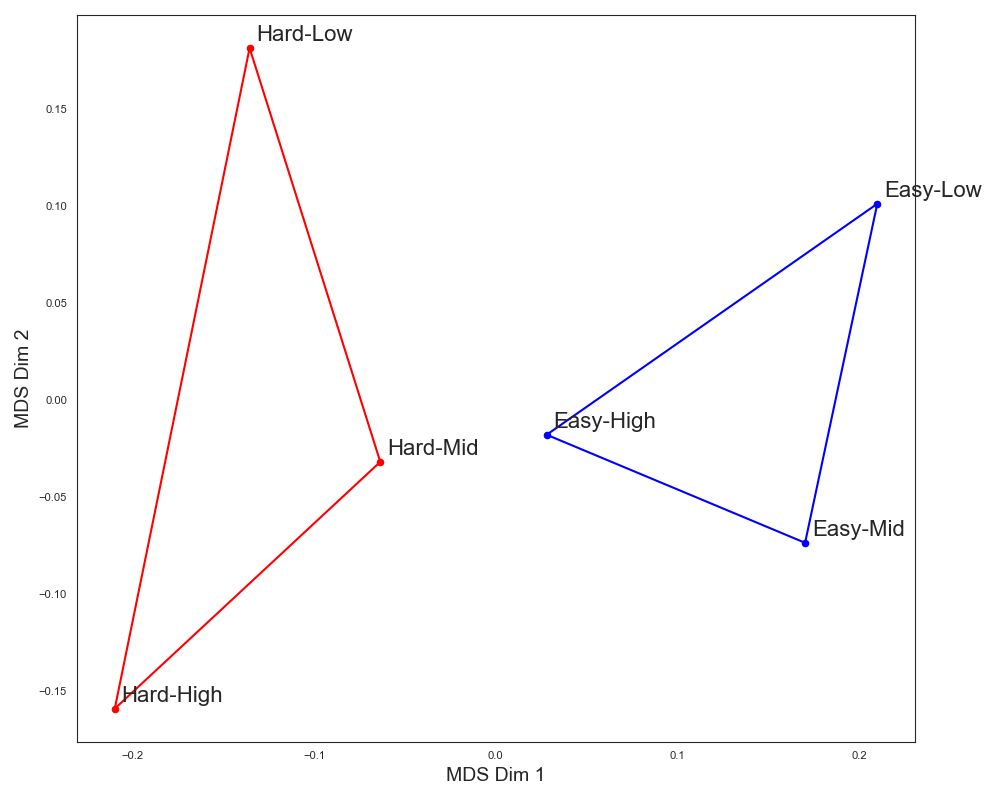

In [29]:
# Usage
fig, ax = plot_mds_homework_2d(to_plot)  # Assuming 'r' is your dissimilarity matrix

### Regression analysis

In [30]:
# model_rdms = [immed_rdm, backgnd_rdm, back_imm_rdm2]
model_rdms = [immed_rdm, backgnd_rdm]

# Perform regression analysis
betas = rdm_regression_analysis_with_intercept(all_rdms_matrices, model_rdms)

In [31]:
# Perform t-tests on coefficients
group_t_stats, group_p_values = t_test_coefficients(betas)

# Print rzesults
regressor_names = ['Immediate', 'Background', 'Back-Imm']
print("Group-level statistics:")
for name, t_stat, p_value in zip(regressor_names, group_t_stats, group_p_values):
    print(f"{name}: t = {t_stat:.4f}, p = {p_value:.8f}")

Group-level statistics:
Immediate: t = 2.3023, p = 0.03508603
Background: t = 3.3771, p = 0.00384102


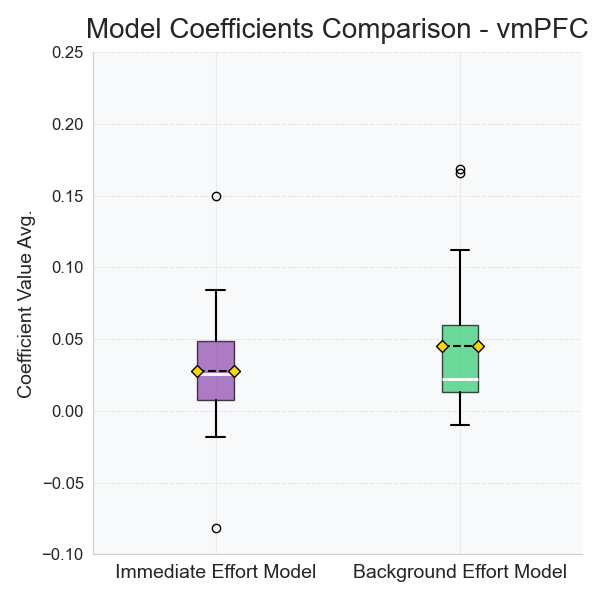

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style and color palette
sns.set_style("whitegrid")
sns.set_palette("deep")

# Adjust gridline transparency
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Set font sizes
SMALL_SIZE = 12
MEDIUM_SIZE = 14
LARGE_SIZE = 20

# Apply font sizes
plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=LARGE_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the boxplot
bp = ax.boxplot(betas, patch_artist=True, meanline=True, showmeans=True)

# Customize boxplot colors
colors = ['#8e44ad', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize other elements
for element in ['whiskers', 'caps', 'medians', 'means']:
    plt.setp(bp[element], color='black', linewidth=1.5)

plt.setp(bp['medians'], color='white', linewidth=2)
plt.setp(bp['means'], marker='D', markeredgecolor='black', markerfacecolor='gold')

# Customize the plot
ax.set_title('Model Coefficients Comparison - vmPFC', fontsize=LARGE_SIZE, pad=10)
ax.set_xticklabels(['Immediate Effort Model', 'Background Effort Model'], fontsize=MEDIUM_SIZE)
ax.set_ylabel('Coefficient Value Avg.', fontsize=MEDIUM_SIZE)
ax.set_ylim(-.1, 0.25)  # Adjust the limits according to your data

# Add a subtle background color
ax.set_facecolor('#f8f9fa')

# Add grid lines
ax.yaxis.grid(True, linestyle='--', which='major', color='#e0e0e0', alpha=0.7)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Adjust layout and display the plot
plt.tight_layout()
# plt.savefig('model_coefficients_vmPFC.png', dpi=300, bbox_inches='tight')
plt.show()